# COVID-19 Clinical Trials Data Science Project

## 1. Introduction

This notebook provides a comprehensive analysis of COVID-19 clinical trials data. We'll explore trial characteristics, intervention types, geographical distribution, timeline patterns, and build predictive models to understand factors influencing trial outcomes and enrollment success.

## 2.1 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

## 2.2 Data Loading

In [2]:
# Load clinical trials dataset
try:
    df_trials = pd.read_csv('COVID clinical trials.csv')
    print('Dataset loaded successfully!')
    print(f'Clinical trials dataset shape: {df_trials.shape}')
except FileNotFoundError as e:
    print(f'Error loading dataset: {e}')

# Display dataset info
print("\nClinical Trials Dataset Preview:")
display(df_trials.head())
print("\nDataset Info:")
print(df_trials.info())
print("\nColumn Names:")
print(df_trials.columns.tolist())

Dataset loaded successfully!
Clinical trials dataset shape: (5783, 27)

Clinical Trials Dataset Preview:


,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,...,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 non-null   object 
 5   Study Results            5783 non-null   object 
 6   Conditions               5783 non-null   object 
 7   Interventions            4897 non-null   object 
 8   Outcome Measures         5748 non-null   object 
 9   Sponsor/Collaborators    5783 non-null   object 
 10  Gender                   5773 non-null   object 
 11  Age                      5783 non-null   object 
 12  Phases                   3322 non-null   object 
 13  Enrollment               5749 non-null   float64
 14  Funded By

## 3. Data Preprocessing and Feature Engineering

In [3]:
# Data cleaning and feature engineering for clinical trials
df = df_trials.copy()

# Clean and process date columns
date_cols = ['Start Date', 'Primary Completion Date', 'Completion Date', 'First Posted']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Extract enrollment numbers
if 'Enrollment' in df.columns:
    df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')

# Process phases
if 'Phases' in df.columns:
    df['Phase_Clean'] = df['Phases'].fillna('Not Applicable')
    df['Phase_Clean'] = df['Phase_Clean'].str.replace('Phase ', '').str.replace('|', '/')

# Process status
if 'Status' in df.columns:
    df['Status_Category'] = df['Status'].map({
        'Completed': 'Completed',
        'Active, not recruiting': 'Active',
        'Recruiting': 'Active', 
        'Not yet recruiting': 'Planned',
        'Suspended': 'Suspended',
        'Terminated': 'Terminated',
        'Withdrawn': 'Withdrawn',
        'Enrolling by invitation': 'Active'
    }).fillna('Other')

# Extract intervention types
if 'Interventions' in df.columns:
    df['Intervention_Type'] = df['Interventions'].str.extract(r'^([^:]+):')
    df['Intervention_Type'] = df['Intervention_Type'].fillna('Other')

# Process study type
if 'Study Type' in df.columns:
    df['Study_Type_Clean'] = df['Study Type'].fillna('Unknown')

# Extract countries from locations
if 'Locations' in df.columns:
    df['Country'] = df['Locations'].str.extract(r', ([^,]+)$')
    df['Country'] = df['Country'].fillna('Unknown')

# Calculate study duration
if 'Start Date' in df.columns and 'Primary Completion Date' in df.columns:
    df['Study_Duration_Days'] = (df['Primary Completion Date'] - df['Start Date']).dt.days

# Time-based features
if 'Start Date' in df.columns:
    df['Start_Year'] = df['Start Date'].dt.year
    df['Start_Month'] = df['Start Date'].dt.month
    df['Start_Quarter'] = df['Start Date'].dt.quarter
    
    # Filter to COVID-relevant timeframe (2018-2023)
    df = df[(df['Start_Year'] >= 2018) & (df['Start_Year'] <= 2023)]

print('Data preprocessing completed')
print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Start Date"].min()} to {df["Start Date"].max()}')
print(f'Unique trials: {len(df)}')
print(f'Countries represented: {df["Country"].nunique()}')

Data preprocessing completed
Dataset shape: (5220, 36)
Date range: 2018-01-01 00:00:00 to 2021-12-01 00:00:00
Unique trials: 5220
Countries represented: 117


## 4. Exploratory Data Analysis

In [4]:
# Clinical trials overview visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Trial Status Distribution', 'Trials by Start Year', 'Study Type Distribution', 'Phase Distribution'],
    specs=[[{'type': 'pie'}, {'type': 'bar'}], [{'type': 'bar'}, {'type': 'bar'}]]
)

# Status distribution
status_counts = df['Status_Category'].value_counts()
fig.add_trace(go.Pie(labels=status_counts.index, values=status_counts.values, name='Status'), row=1, col=1)

# Trials by year
year_counts = df['Start_Year'].value_counts().sort_index()
fig.add_trace(go.Bar(x=year_counts.index, y=year_counts.values, name='Year'), row=1, col=2)

# Study type distribution
study_counts = df['Study_Type_Clean'].value_counts().head(10)
fig.add_trace(go.Bar(x=study_counts.values, y=study_counts.index, orientation='h', name='Study Type'), row=2, col=1)

# Phase distribution
phase_counts = df['Phase_Clean'].value_counts().head(8)
fig.add_trace(go.Bar(x=phase_counts.index, y=phase_counts.values, name='Phase'), row=2, col=2)

fig.update_layout(height=800, title_text='COVID-19 Clinical Trials Overview', showlegend=False)
fig.show()

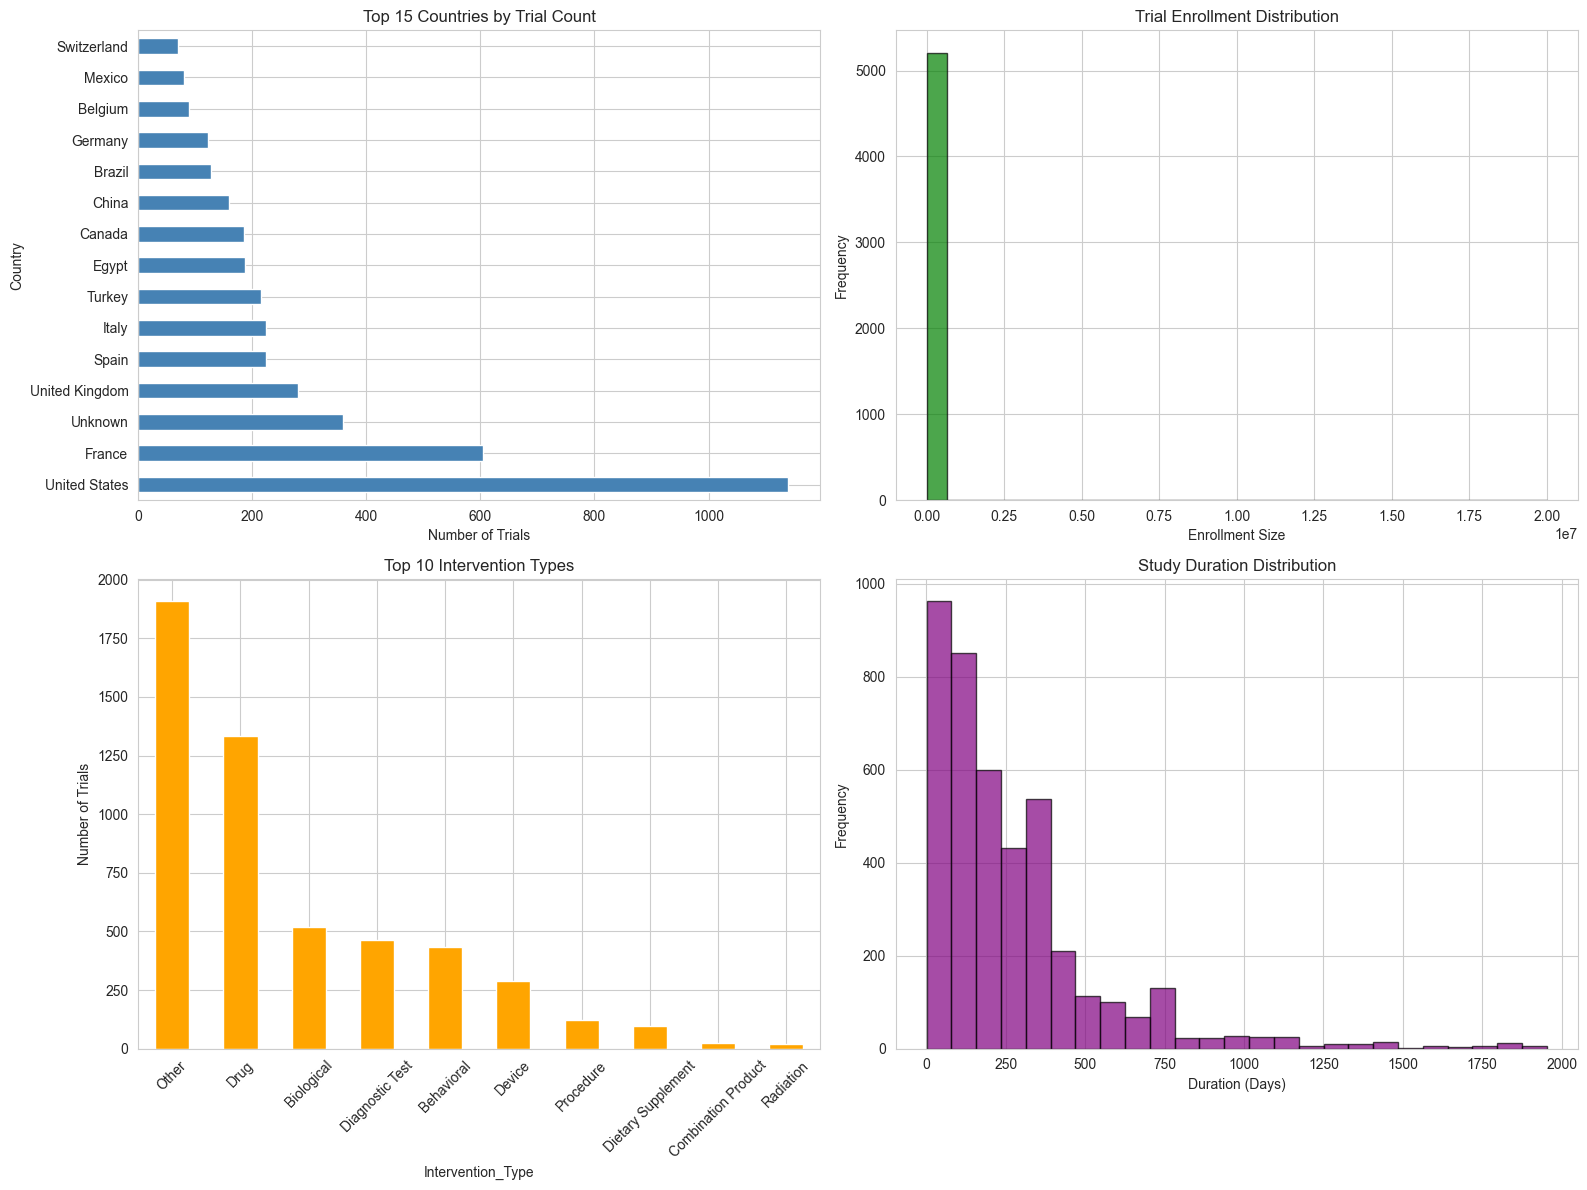

In [5]:
# Detailed analysis visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top countries by trial count
country_counts = df['Country'].value_counts().head(15)
country_counts.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 15 Countries by Trial Count')
axes[0,0].set_xlabel('Number of Trials')

# Enrollment distribution
if 'Enrollment' in df.columns:
    enrollment_data = df['Enrollment'].dropna()
    axes[0,1].hist(enrollment_data, bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0,1].set_title('Trial Enrollment Distribution')
    axes[0,1].set_xlabel('Enrollment Size')
    axes[0,1].set_ylabel('Frequency')

# Intervention types
intervention_counts = df['Intervention_Type'].value_counts().head(10)
intervention_counts.plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Top 10 Intervention Types')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylabel('Number of Trials')

# Study duration analysis
if 'Study_Duration_Days' in df.columns:
    duration_data = df['Study_Duration_Days'].dropna()
    duration_data = duration_data[(duration_data > 0) & (duration_data < 2000)]  # Filter outliers
    axes[1,1].hist(duration_data, bins=25, edgecolor='black', alpha=0.7, color='purple')
    axes[1,1].set_title('Study Duration Distribution')
    axes[1,1].set_xlabel('Duration (Days)')
    axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Statistical Analysis

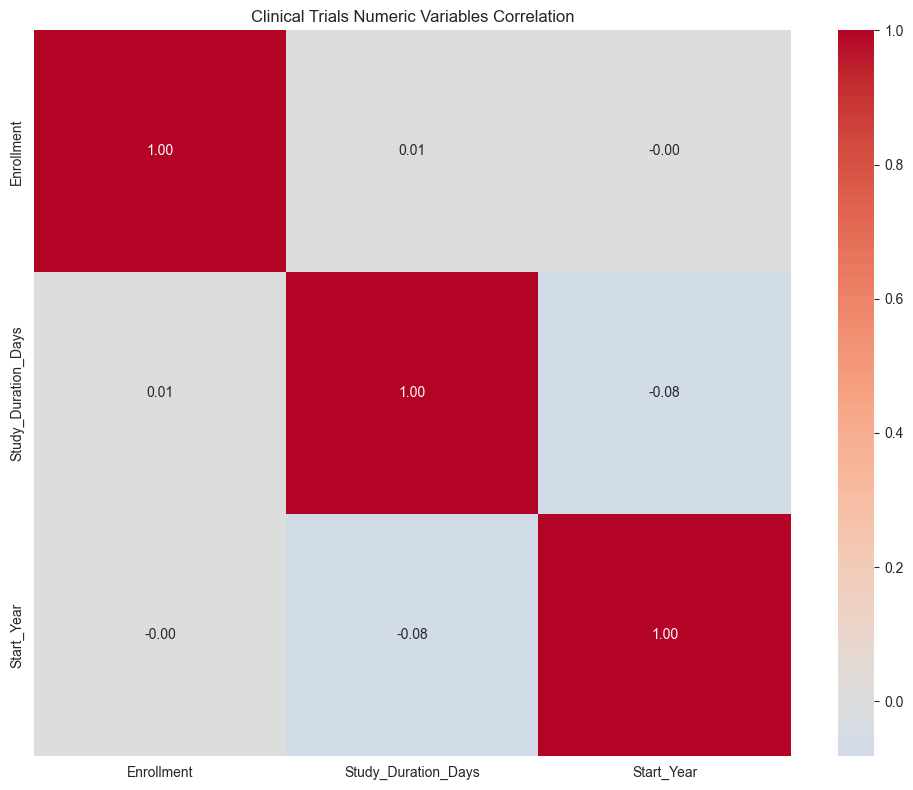

=== CLINICAL TRIALS KEY STATISTICS ===
Total Trials: 5,220
Countries Involved: 117
Study Types: 2

Enrollment Statistics:
  Mean: 16937 participants
  Median: 178 participants
  Max: 20000000 participants

Study Duration Statistics:
  Mean: 299 days
  Median: 186 days

Trial Status Distribution:
  Active: 3395 (65.0%)
  Completed: 1016 (19.5%)
  Planned: 638 (12.2%)
  Terminated: 74 (1.4%)
  Withdrawn: 71 (1.4%)
  Suspended: 26 (0.5%)


In [6]:
# Statistical analysis of clinical trials
numeric_cols = ['Enrollment', 'Study_Duration_Days', 'Start_Year']
available_numeric = [col for col in numeric_cols if col in df.columns]

if len(available_numeric) > 1:
    correlation_matrix = df[available_numeric].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Clinical Trials Numeric Variables Correlation')
    plt.tight_layout()
    plt.show()

# Key statistics
print('=== CLINICAL TRIALS KEY STATISTICS ===')
print(f'Total Trials: {len(df):,}')
print(f'Countries Involved: {df["Country"].nunique()}')
print(f'Study Types: {df["Study_Type_Clean"].nunique()}')

if 'Enrollment' in df.columns:
    enrollment_stats = df['Enrollment'].describe()
    print(f'\nEnrollment Statistics:')
    print(f'  Mean: {enrollment_stats["mean"]:.0f} participants')
    print(f'  Median: {enrollment_stats["50%"]:.0f} participants')
    print(f'  Max: {enrollment_stats["max"]:.0f} participants')

if 'Study_Duration_Days' in df.columns:
    duration_stats = df['Study_Duration_Days'].dropna().describe()
    print(f'\nStudy Duration Statistics:')
    print(f'  Mean: {duration_stats["mean"]:.0f} days')
    print(f'  Median: {duration_stats["50%"]:.0f} days')

# Status analysis
print(f'\nTrial Status Distribution:')
for status, count in df['Status_Category'].value_counts().items():
    percentage = (count / len(df)) * 100
    print(f'  {status}: {count} ({percentage:.1f}%)')

## 6. Machine Learning Models

In [7]:
# Prepare data for modeling - Predict enrollment success
df_model = df.copy()

# Create target variable: High enrollment (above median)
if 'Enrollment' in df_model.columns:
    median_enrollment = df_model['Enrollment'].median()
    df_model['High_Enrollment'] = (df_model['Enrollment'] > median_enrollment).astype(int)
    
    # Encode categorical variables
    le_status = LabelEncoder()
    le_phase = LabelEncoder()
    le_intervention = LabelEncoder()
    le_country = LabelEncoder()
    
    df_model['Status_Encoded'] = le_status.fit_transform(df_model['Status_Category'])
    df_model['Phase_Encoded'] = le_phase.fit_transform(df_model['Phase_Clean'])
    df_model['Intervention_Encoded'] = le_intervention.fit_transform(df_model['Intervention_Type'])
    df_model['Country_Encoded'] = le_country.fit_transform(df_model['Country'])
    
    # Select features for modeling
    feature_cols = ['Status_Encoded', 'Phase_Encoded', 'Intervention_Encoded', 
                   'Country_Encoded', 'Start_Year']
    
    # Remove rows with missing values in key columns
    model_data = df_model[feature_cols + ['High_Enrollment']].dropna()
    
    if len(model_data) > 100:  # Ensure sufficient data
        X = model_data[feature_cols]
        y = model_data['High_Enrollment']
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Train classification models
        models = {
            'Logistic Regression': LogisticRegression(random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
        }
        
        results = {}
        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            results[name] = {'Accuracy': accuracy}
            
            print(f'\n{name} Results:')
            print(f'Accuracy: {accuracy:.3f}')
            print('Classification Report:')
            print(classification_report(y_test, y_pred))
        
        # Store best model for feature importance
        best_model = models['Random Forest']
        
    else:
        print('Insufficient data for modeling')
else:
    print('Enrollment column not available for modeling')


Logistic Regression Results:
Accuracy: 0.566
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.49      0.53       512
           1       0.57      0.64      0.60       532

    accuracy                           0.57      1044
   macro avg       0.57      0.56      0.56      1044
weighted avg       0.57      0.57      0.56      1044


Random Forest Results:
Accuracy: 0.628
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.54      0.59       512
           1       0.62      0.71      0.66       532

    accuracy                           0.63      1044
   macro avg       0.63      0.63      0.63      1044
weighted avg       0.63      0.63      0.63      1044



## 7. Feature Importance and Insights

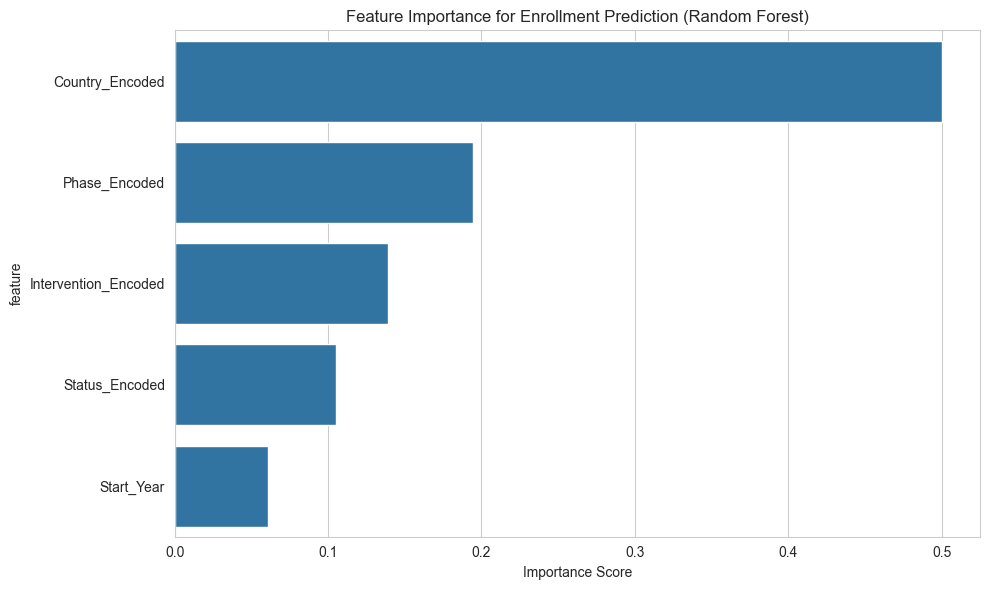

Feature Importance Ranking:
Country_Encoded: 0.500
Phase_Encoded: 0.195
Intervention_Encoded: 0.139
Status_Encoded: 0.105
Start_Year: 0.061

=== TRIAL INSIGHTS ===

Enrollment by Phase:
                   mean  median  count
Phase_Clean                           
1                  85.0    40.0    203
1/2               252.0    79.0    166
2                 562.0   100.0    600
2/3              1564.0   320.0    175
3                3392.0   372.0    395
4                1530.0   137.0    153
Early 1            80.0    36.0     41
Not Applicable  24710.0   200.0   3487

Top 5 Intervention Types:
  Other: 1908 trials
  Drug: 1335 trials
  Biological: 520 trials
  Diagnostic Test: 463 trials
  Behavioral: 434 trials

Trials Started by Year:
  2018: 39 trials
  2019: 93 trials
  2020: 4245 trials
  2021: 843 trials


In [8]:
# Feature importance analysis
if 'best_model' in locals() and hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title('Feature Importance for Enrollment Prediction (Random Forest)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    
    print('Feature Importance Ranking:')
    for _, row in feature_importance.iterrows():
        print(f'{row["feature"]}: {row["importance"]:.3f}')

# Additional insights
print('\n=== TRIAL INSIGHTS ===')

# Phase analysis
if 'Phase_Clean' in df.columns and 'Enrollment' in df.columns:
    phase_enrollment = df.groupby('Phase_Clean')['Enrollment'].agg(['mean', 'median', 'count']).round(0)
    print('\nEnrollment by Phase:')
    print(phase_enrollment)

# Intervention type analysis
if 'Intervention_Type' in df.columns:
    intervention_counts = df['Intervention_Type'].value_counts().head(5)
    print('\nTop 5 Intervention Types:')
    for intervention, count in intervention_counts.items():
        print(f'  {intervention}: {count} trials')

# Timeline analysis
if 'Start_Year' in df.columns:
    yearly_trends = df.groupby('Start_Year').size()
    print('\nTrials Started by Year:')
    for year, count in yearly_trends.items():
        if pd.notna(year):
            print(f'  {int(year)}: {count} trials')

## 8. Advanced Clinical Trials Analysis

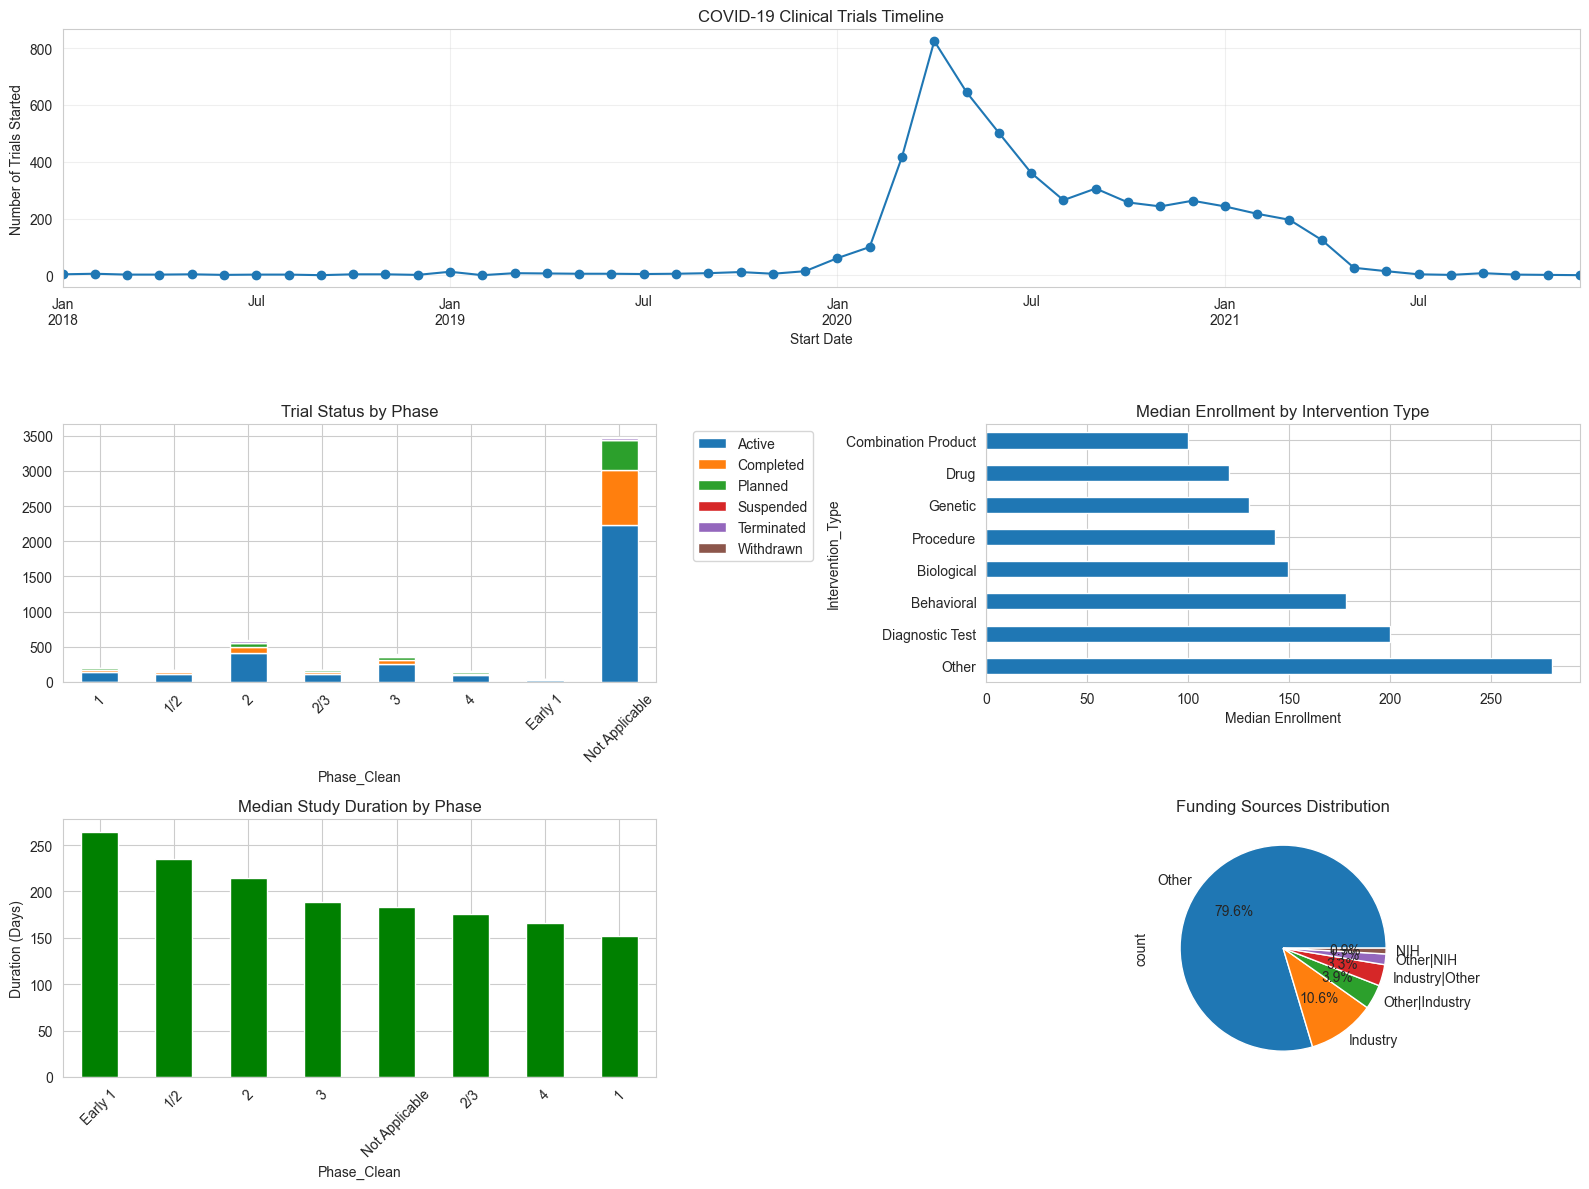


=== COMPREHENSIVE TRIAL STATISTICS ===
Total Trials Analyzed: 5,220
Unique Countries: 117
Date Range: 2018-01-01 to 2021-12-01
Total Planned Participants: 88,412,750
Average Trial Size: 16937 participants

Most Common Intervention: Other
Most Active Country: United States


In [9]:
# Advanced analysis and visualizations

# Geographic distribution analysis
fig = plt.figure(figsize=(16, 12))

# Create subplots
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

# Timeline of trial starts
if 'Start Date' in df.columns:
    monthly_starts = df.set_index('Start Date').resample('M').size()
    monthly_starts.plot(ax=ax1, kind='line', marker='o')
    ax1.set_title('COVID-19 Clinical Trials Timeline')
    ax1.set_ylabel('Number of Trials Started')
    ax1.grid(True, alpha=0.3)

# Status vs Phase analysis
if 'Status_Category' in df.columns and 'Phase_Clean' in df.columns:
    status_phase = pd.crosstab(df['Phase_Clean'], df['Status_Category'])
    status_phase.plot(kind='bar', stacked=True, ax=ax2)
    ax2.set_title('Trial Status by Phase')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Enrollment by intervention type
if 'Intervention_Type' in df.columns and 'Enrollment' in df.columns:
    intervention_enrollment = df.groupby('Intervention_Type')['Enrollment'].median().sort_values(ascending=False).head(8)
    intervention_enrollment.plot(kind='barh', ax=ax3)
    ax3.set_title('Median Enrollment by Intervention Type')
    ax3.set_xlabel('Median Enrollment')

# Study duration analysis
if 'Study_Duration_Days' in df.columns and 'Phase_Clean' in df.columns:
    duration_by_phase = df.groupby('Phase_Clean')['Study_Duration_Days'].median().sort_values(ascending=False)
    duration_by_phase.plot(kind='bar', ax=ax4, color='green')
    ax4.set_title('Median Study Duration by Phase')
    ax4.set_ylabel('Duration (Days)')
    ax4.tick_params(axis='x', rotation=45)

# Funding source analysis
if 'Funded Bys' in df.columns:
    funding_counts = df['Funded Bys'].value_counts().head(6)
    funding_counts.plot(kind='pie', ax=ax5, autopct='%1.1f%%')
    ax5.set_title('Funding Sources Distribution')

plt.tight_layout()
plt.show()

# Summary statistics
print('\n=== COMPREHENSIVE TRIAL STATISTICS ===')
print(f'Total Trials Analyzed: {len(df):,}')
print(f'Unique Countries: {df["Country"].nunique()}')
print(f'Date Range: {df["Start Date"].min().strftime("%Y-%m-%d")} to {df["Start Date"].max().strftime("%Y-%m-%d")}')

if 'Enrollment' in df.columns:
    total_participants = df['Enrollment'].sum()
    print(f'Total Planned Participants: {total_participants:,.0f}')
    print(f'Average Trial Size: {df["Enrollment"].mean():.0f} participants')

print(f'\nMost Common Intervention: {df["Intervention_Type"].mode().iloc[0]}')
print(f'Most Active Country: {df["Country"].mode().iloc[0]}')

## 9. Interactive Visualizations

In [10]:
# Interactive visualizations using Plotly

# Geographic distribution of trials
country_trial_counts = df['Country'].value_counts().head(20)
fig1 = px.bar(x=country_trial_counts.values, y=country_trial_counts.index, 
              orientation='h', title='Top 20 Countries by Number of COVID-19 Trials',
              labels={'x': 'Number of Trials', 'y': 'Country'})
fig1.update_layout(height=600)
fig1.show()

# Timeline visualization
if 'Start Date' in df.columns and 'Status_Category' in df.columns:
    timeline_data = df.groupby([df['Start Date'].dt.to_period('M'), 'Status_Category']).size().reset_index()
    timeline_data['Start Date'] = timeline_data['Start Date'].astype(str)
    
    fig2 = px.bar(timeline_data, x='Start Date', y=0, color='Status_Category',
                  title='COVID-19 Clinical Trials Timeline by Status',
                  labels={'0': 'Number of Trials'})
    fig2.update_layout(height=500, xaxis_tickangle=-45)
    fig2.show()

# Enrollment vs Duration scatter plot
if 'Enrollment' in df.columns and 'Study_Duration_Days' in df.columns:
    scatter_data = df.dropna(subset=['Enrollment', 'Study_Duration_Days', 'Phase_Clean'])
    scatter_data = scatter_data[(scatter_data['Study_Duration_Days'] > 0) & 
                               (scatter_data['Study_Duration_Days'] < 1500)]
    
    fig3 = px.scatter(scatter_data, x='Study_Duration_Days', y='Enrollment', 
                      color='Phase_Clean', size='Enrollment',
                      title='Trial Enrollment vs Study Duration by Phase',
                      labels={'Study_Duration_Days': 'Study Duration (Days)', 
                             'Enrollment': 'Planned Enrollment'})
    fig3.update_layout(height=500)
    fig3.show()

## 10. Key Findings and Recommendations

In [14]:
# Generate comprehensive insights
print('=== COVID-19 CLINICAL TRIALS ANALYSIS INSIGHTS ===\n')

# Key findings
print('1. TRIAL LANDSCAPE OVERVIEW:')
print(f'   • Total trials analyzed: {len(df):,}')
print(f'   • Countries involved: {df["Country"].nunique()}')
print(f'   • Most active country: {df["Country"].mode().iloc[0]} ({df["Country"].value_counts().iloc[0]} trials)')

if 'Enrollment' in df.columns:
    total_enrollment = df['Enrollment'].sum()
    print(f'   • Total planned participants: {total_enrollment:,.0f}')
    print(f'   • Average trial size: {df["Enrollment"].mean():.0f} participants')

print('\n2. INTERVENTION PATTERNS:')
intervention_analysis = df['Intervention_Type'].value_counts().head(3)
for i, (intervention, count) in enumerate(intervention_analysis.items(), 1):
    percentage = (count / len(df)) * 100
    print(f'   • #{i}: {intervention} - {count} trials ({percentage:.1f}%)')

print('\n3. TRIAL STATUS INSIGHTS:')
status_analysis = df['Status_Category'].value_counts()
for status, count in status_analysis.items():
    percentage = (count / len(df)) * 100
    print(f'   • {status}: {count} trials ({percentage:.1f}%)')

print('\n4. PHASE DISTRIBUTION:')
if 'Phase_Clean' in df.columns:
    phase_analysis = df['Phase_Clean'].value_counts().head(5)
    for phase, count in phase_analysis.items():
        percentage = (count / len(df)) * 100
        print(f'   • {phase}: {count} trials ({percentage:.1f}%)')

print('\n5. TIMELINE INSIGHTS:')
if 'Start_Year' in df.columns:
    year_analysis = df['Start_Year'].value_counts().sort_index()
    peak_year = year_analysis.idxmax()
    print(f'   • Peak year for trial initiation: {int(peak_year)} ({year_analysis.max()} trials)')
    print(f'   • Trial activity span: {int(df["Start_Year"].min())} - {int(df["Start_Year"].max())}')


=== COVID-19 CLINICAL TRIALS ANALYSIS INSIGHTS ===

1. TRIAL LANDSCAPE OVERVIEW:
   • Total trials analyzed: 5,220
   • Countries involved: 117
   • Most active country: United States (1139 trials)
   • Total planned participants: 88,412,750
   • Average trial size: 16937 participants

2. INTERVENTION PATTERNS:
   • #1: Other - 1908 trials (36.6%)
   • #2: Drug - 1335 trials (25.6%)
   • #3: Biological - 520 trials (10.0%)

3. TRIAL STATUS INSIGHTS:
   • Active: 3395 trials (65.0%)
   • Completed: 1016 trials (19.5%)
   • Planned: 638 trials (12.2%)
   • Terminated: 74 trials (1.4%)
   • Withdrawn: 71 trials (1.4%)
   • Suspended: 26 trials (0.5%)

4. PHASE DISTRIBUTION:
   • Not Applicable: 3487 trials (66.8%)
   • 2: 600 trials (11.5%)
   • 3: 395 trials (7.6%)
   • 1: 203 trials (3.9%)
   • 2/3: 175 trials (3.4%)

5. TIMELINE INSIGHTS:
   • Peak year for trial initiation: 2020 (4245 trials)
   • Trial activity span: 2018 - 2021
